In [1]:
"""VAE U-DiT mini 2: interactive notebook experiment.

Explores diffusion-transformer image generation using the raw architecture and
DiffusionModel wrapper selected in its cells. Related numbered copies retain their own
architecture, conditioning, reshaping, and training choices; this file uses the literal
values written below.

Inputs are loaded image/label arrays and the model, schedule, optimizer, callback, and
fit settings in the setup cells. get_dataset documents byte scaling, optional channel
insertion, label handling, shuffle behavior, and batch defaults. Wrapper
constructor/method docstrings define the remaining selected modes.

Outputs include a trained model, fit histories, sampled images, and any configured
callback/checkpoint files. Executing cells may download data, allocate TensorFlow
resources, train weights, and write artifacts. Cell definitions do not run a complete
experiment automatically, and notebook-wide names depend on prior setup execution.
"""

import init

In [2]:
epochs = 50 # or 50 to get acc of 0.9850

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    use_cfg=False, 
    dim=8, 
    dim_forced=False, 
    depth=15, 
    connection_ids_dict={8: (3,), 10: (1,), 12: (7,)}, 
    cross_attention_ids_dict={13: (9,), 15: (11,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 13, 15], 
    use_decoder_ids=[13, 15], 
    vit_block_mlp_output_dims={1: 8, 3: 16, 5: 16, 13: 8, 15: 8}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos", 
    }, 
    upsample_ids=[12, 14], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }, 
    reshaper_ids_dict={
        6: "flatten", 7: "unflatten", 
        8: "flatten", 9: "unflatten", 
        10: "flatten", 11: "unflatten"
    }, 
    reshaper_kwargs={
        "add_kl": True, 
        "latent_dim_ratio": [1 / 32, 1 / 128, 1 / 256]
    }
)
model = DiffusionModel(
    network=vit, 
    swap_noise_image=True, 
    kl_loss_coef=0.01, 
    modify_first_t=True, 
    train_noisified_max_timesteps=0, 
    test_noisified_max_timesteps=0, 
) # 

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 8)           40        
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 8)                8000      
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 8)                80        
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 8)                0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 8) 

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset), #  * 11
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
    # run_eagerly=True
)

In [7]:
from tensorflow.keras import callbacks

from diffusion import ImageGeneratorCallback
from common.lr_logger_callback import LrLoggerCallback


callbacks_list = [
    LrLoggerCallback(), 
    callbacks.ProgbarLogger(count_mode="steps"), 
    ImageGeneratorCallback(), 
]

In [8]:
# model.set_current_resolution(14)

In [9]:
# model.set_current_resolution(28)

In [10]:
# model.set_current_resolution(56)

In [11]:
# model.set_current_resolution(16)

Epoch 1/50
468/468 [==============================] - 67s 113ms/step - loss: 0.2714 - noise_loss: 0.2657 - kl_loss: 0.5635 - val_loss: 0.8028 - val_noise_loss: 0.6567 - val_image_loss: 0.0000e+00 - val_kl_loss: 14.6096 - learning_rate: 9.9901e-04


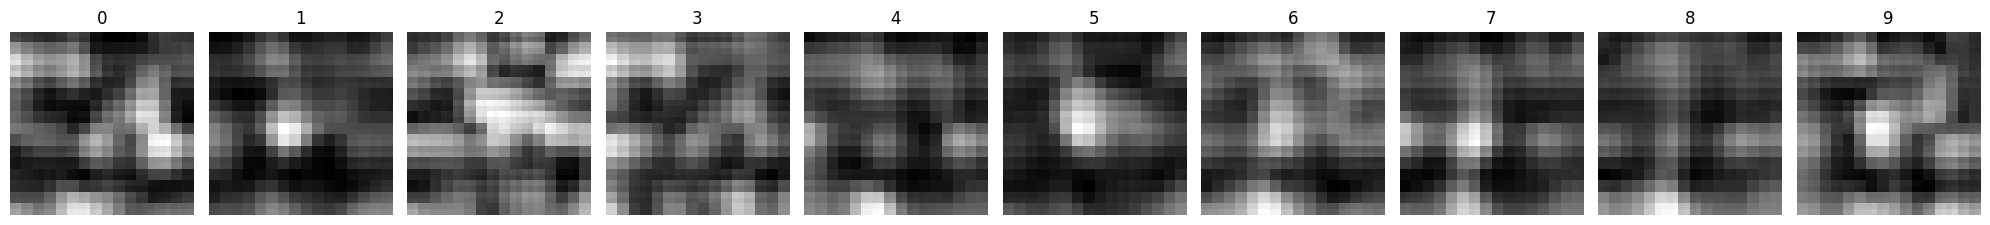

Epoch 2/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1853 - noise_loss: 0.1836 - kl_loss: 0.1683 - val_loss: 0.4633 - val_noise_loss: 0.4091 - val_image_loss: 0.0000e+00 - val_kl_loss: 5.4163 - learning_rate: 9.9606e-04


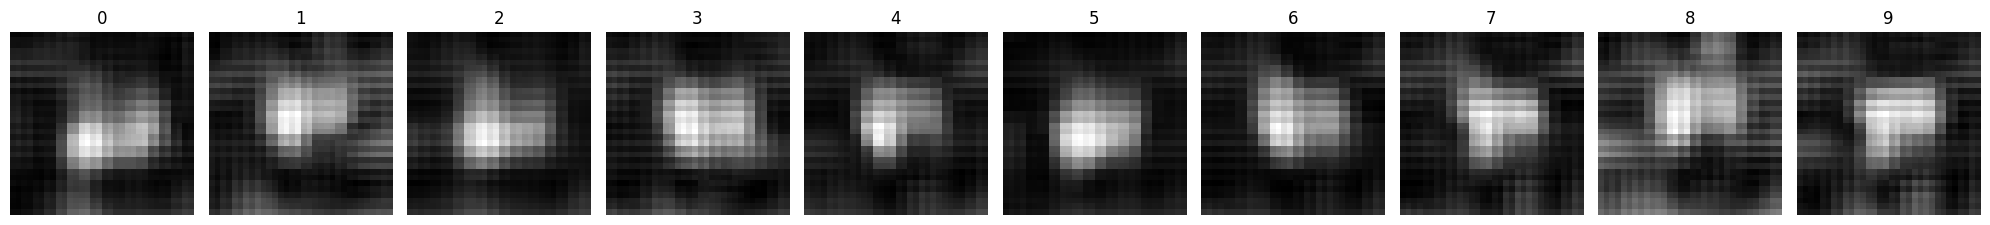

Epoch 3/50
468/468 [==============================] - 52s 110ms/step - loss: 0.1736 - noise_loss: 0.1707 - kl_loss: 0.2844 - val_loss: 0.3143 - val_noise_loss: 0.2927 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.1584 - learning_rate: 9.9114e-04


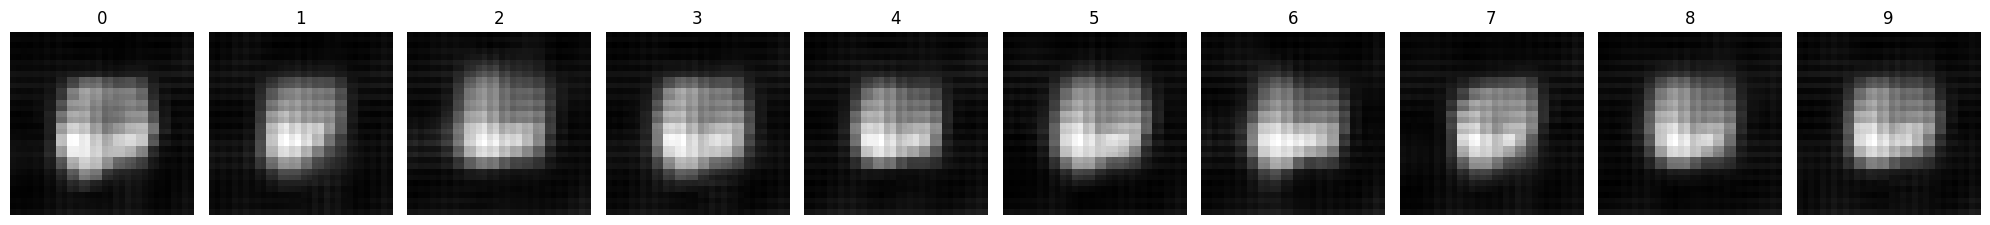

Epoch 4/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1694 - noise_loss: 0.1653 - kl_loss: 0.4120 - val_loss: 0.2450 - val_noise_loss: 0.2353 - val_image_loss: 0.0000e+00 - val_kl_loss: 0.9696 - learning_rate: 9.8429e-04


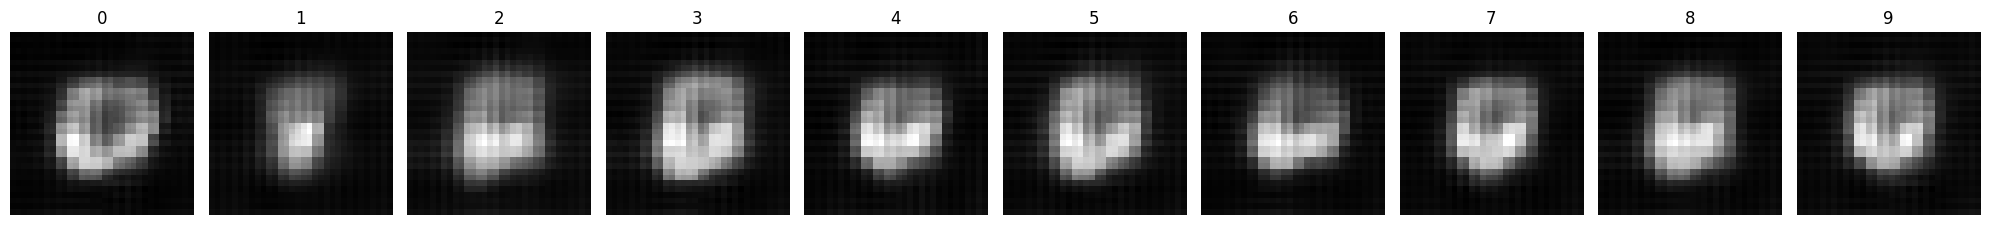

Epoch 5/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1618 - noise_loss: 0.1502 - kl_loss: 1.1512 - val_loss: 0.2060 - val_noise_loss: 0.1999 - val_image_loss: 0.0000e+00 - val_kl_loss: 0.6106 - learning_rate: 9.7553e-04


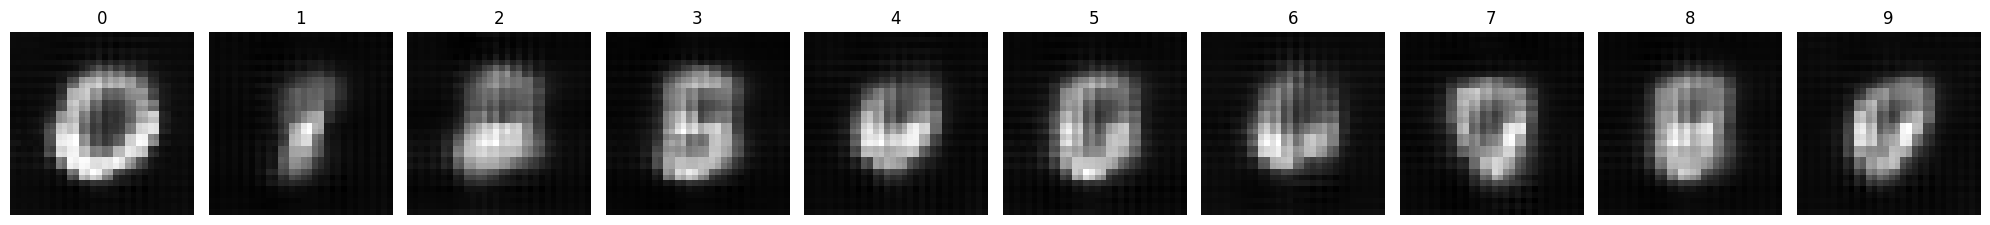

Epoch 6/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1554 - noise_loss: 0.1408 - kl_loss: 1.4624 - val_loss: 0.1842 - val_noise_loss: 0.1773 - val_image_loss: 0.0000e+00 - val_kl_loss: 0.6860 - learning_rate: 9.6489e-04


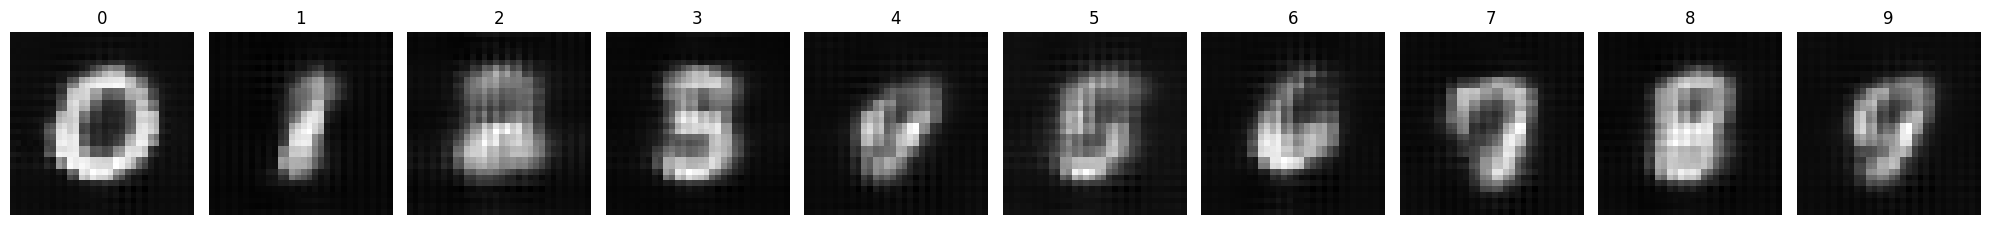

Epoch 7/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1520 - noise_loss: 0.1360 - kl_loss: 1.5972 - val_loss: 0.1722 - val_noise_loss: 0.1634 - val_image_loss: 0.0000e+00 - val_kl_loss: 0.8788 - learning_rate: 9.5241e-04


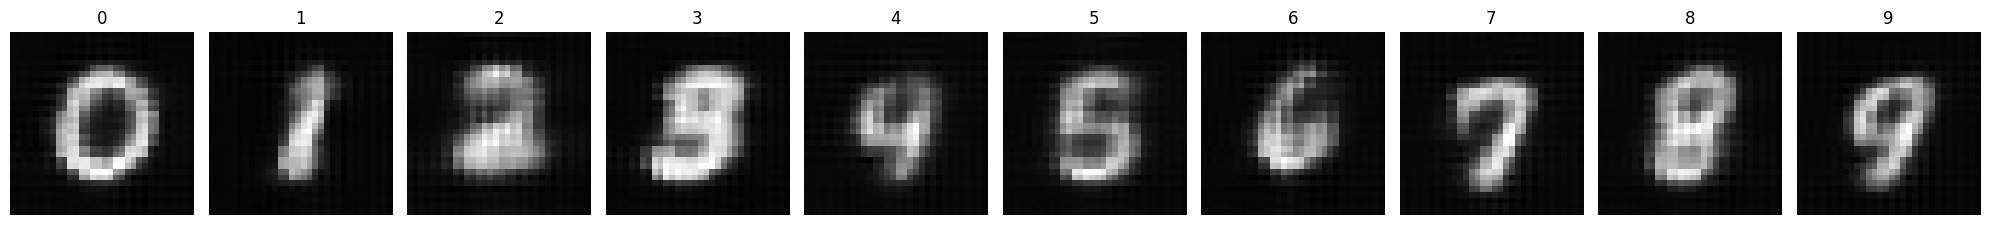

Epoch 8/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1496 - noise_loss: 0.1324 - kl_loss: 1.7126 - val_loss: 0.1633 - val_noise_loss: 0.1524 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.0969 - learning_rate: 9.3815e-04


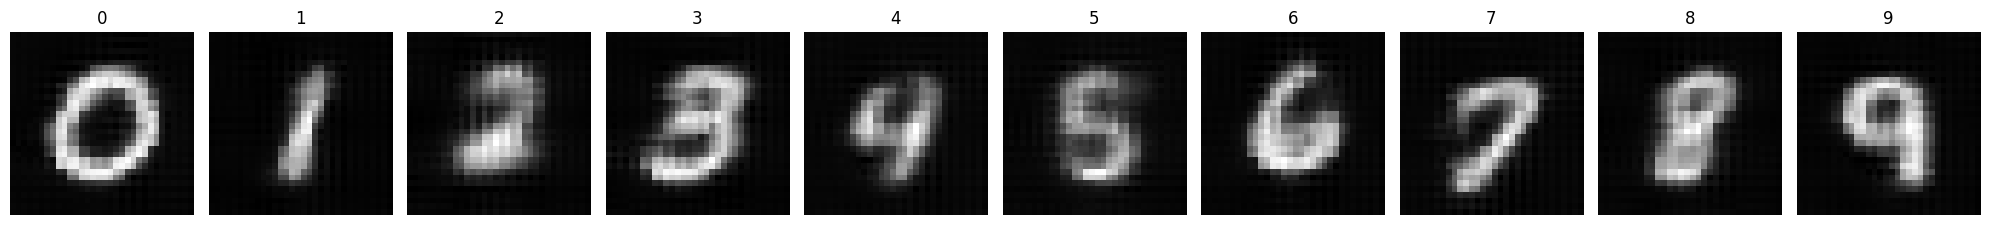

Epoch 9/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1479 - noise_loss: 0.1301 - kl_loss: 1.7792 - val_loss: 0.1563 - val_noise_loss: 0.1432 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.3039 - learning_rate: 9.2216e-04


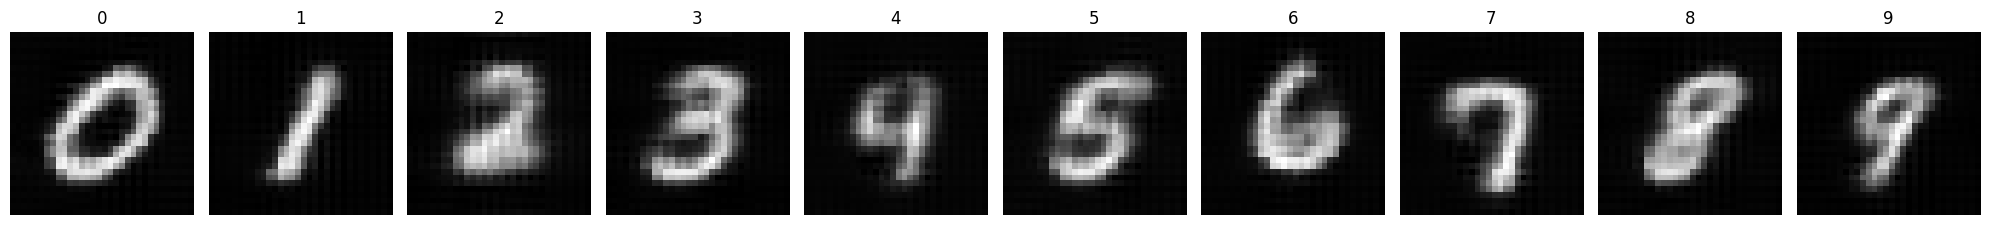

Epoch 10/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1463 - noise_loss: 0.1278 - kl_loss: 1.8489 - val_loss: 0.1509 - val_noise_loss: 0.1360 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.4846 - learning_rate: 9.0451e-04


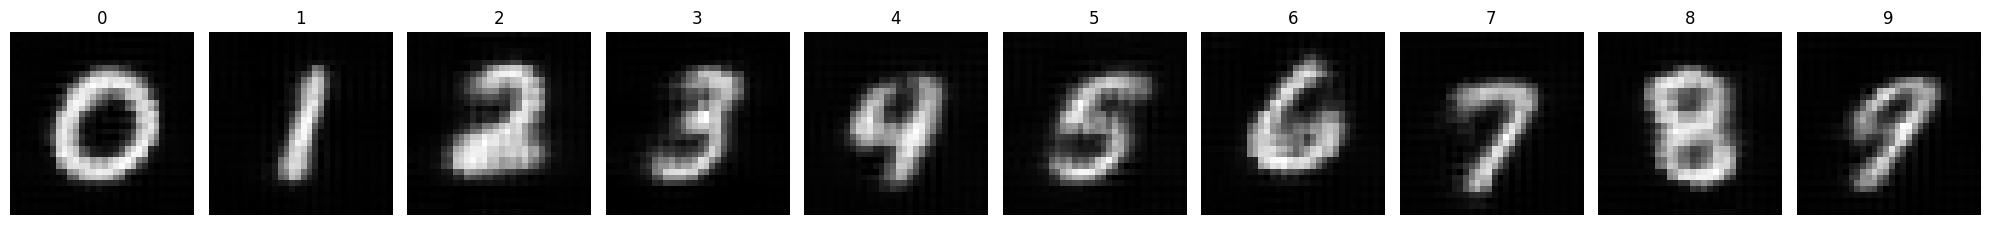

Epoch 11/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1455 - noise_loss: 0.1264 - kl_loss: 1.9041 - val_loss: 0.1472 - val_noise_loss: 0.1308 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.6326 - learning_rate: 8.8526e-04


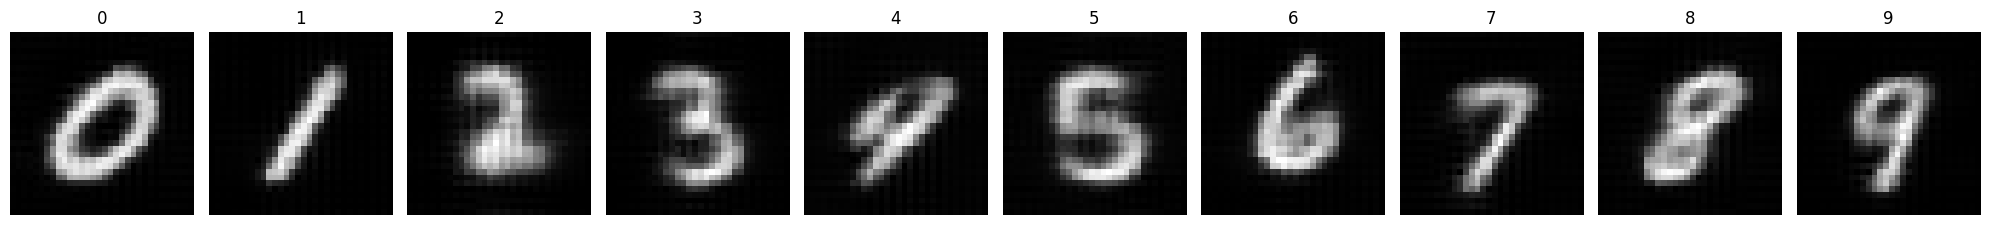

Epoch 12/50
468/468 [==============================] - 50s 108ms/step - loss: 0.1446 - noise_loss: 0.1253 - kl_loss: 1.9304 - val_loss: 0.1449 - val_noise_loss: 0.1276 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.7291 - learning_rate: 8.6448e-04


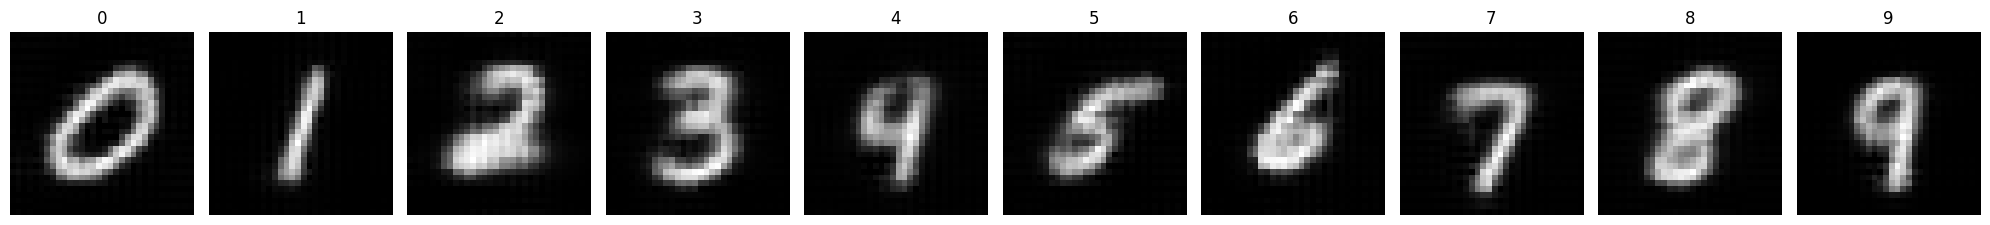

Epoch 13/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1438 - noise_loss: 0.1241 - kl_loss: 1.9702 - val_loss: 0.1434 - val_noise_loss: 0.1254 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.8047 - learning_rate: 8.4227e-04


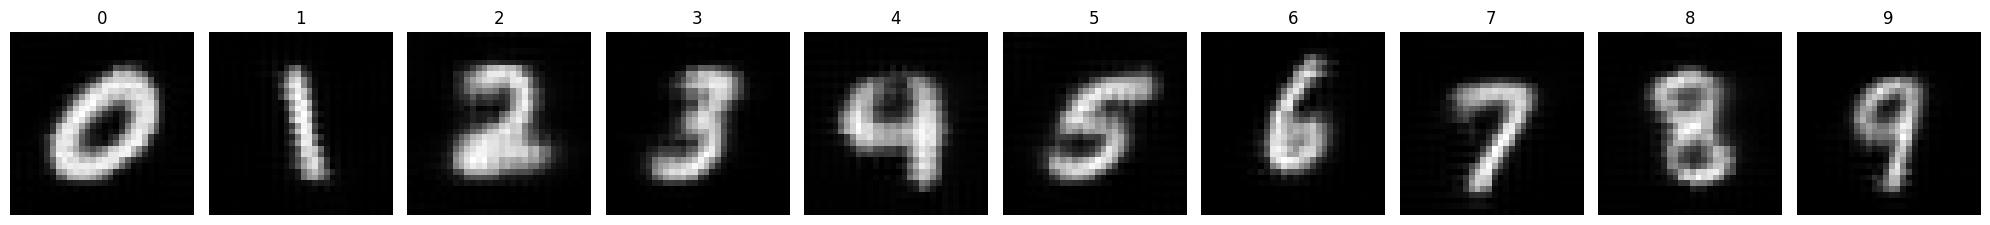

Epoch 14/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1431 - noise_loss: 0.1232 - kl_loss: 1.9954 - val_loss: 0.1424 - val_noise_loss: 0.1238 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.8601 - learning_rate: 8.1871e-04


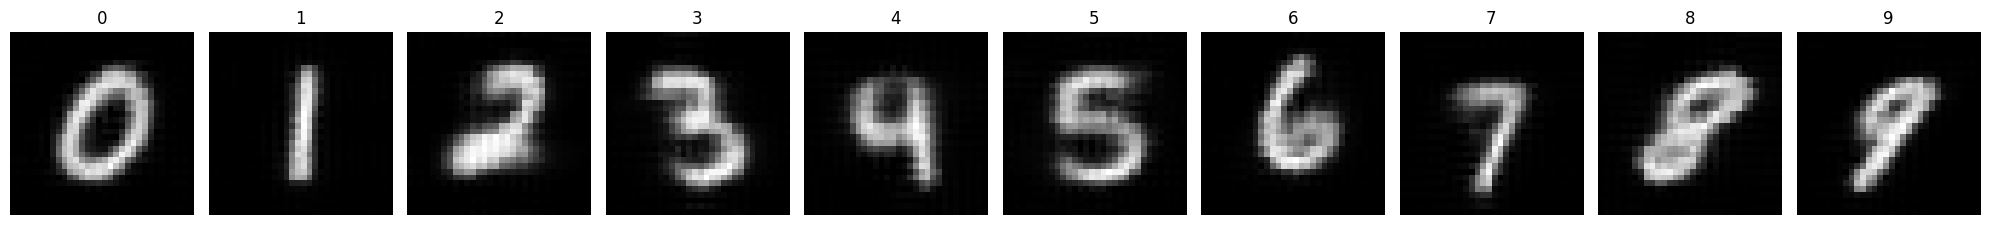

Epoch 15/50
468/468 [==============================] - 51s 108ms/step - loss: 0.1427 - noise_loss: 0.1224 - kl_loss: 2.0215 - val_loss: 0.1416 - val_noise_loss: 0.1225 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.9064 - learning_rate: 7.9389e-04


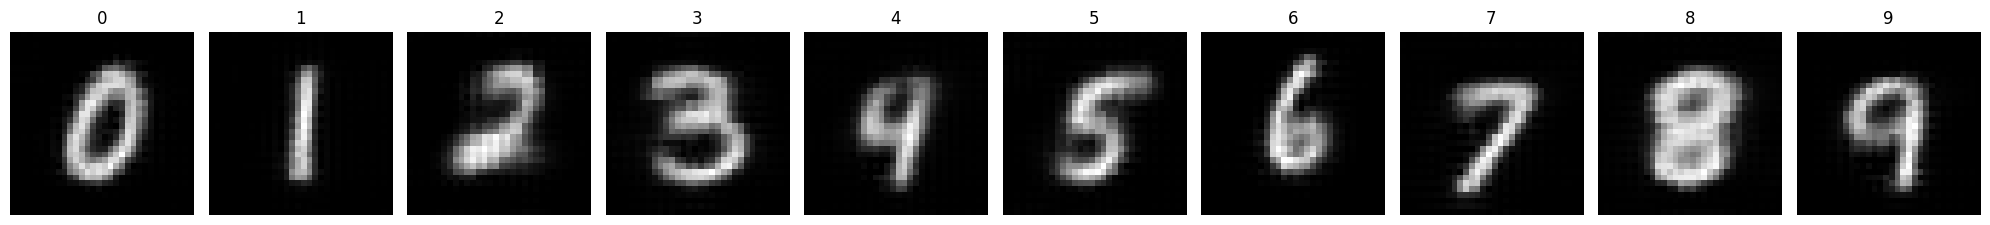

Epoch 16/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1421 - noise_loss: 0.1217 - kl_loss: 2.0410 - val_loss: 0.1411 - val_noise_loss: 0.1217 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.9410 - learning_rate: 7.6791e-04


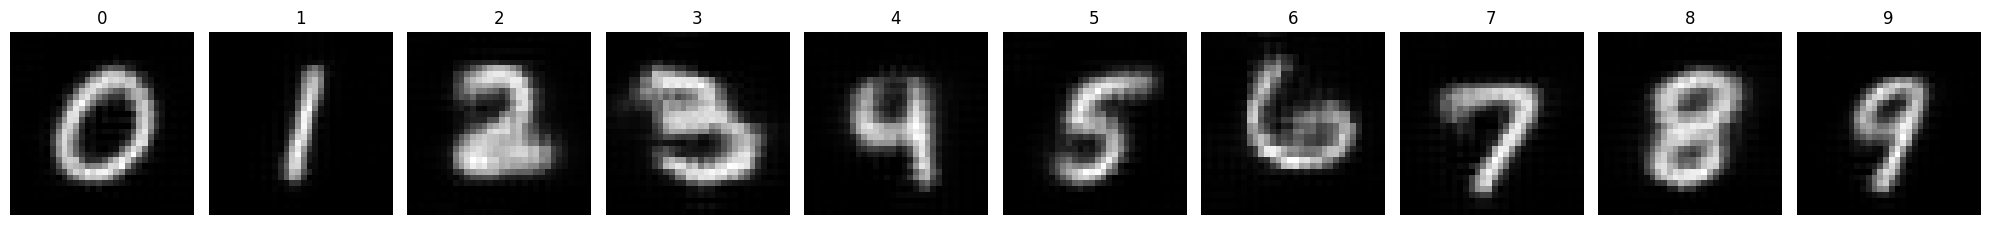

Epoch 17/50
468/468 [==============================] - 51s 108ms/step - loss: 0.1415 - noise_loss: 0.1208 - kl_loss: 2.0699 - val_loss: 0.1404 - val_noise_loss: 0.1207 - val_image_loss: 0.0000e+00 - val_kl_loss: 1.9741 - learning_rate: 7.4088e-04


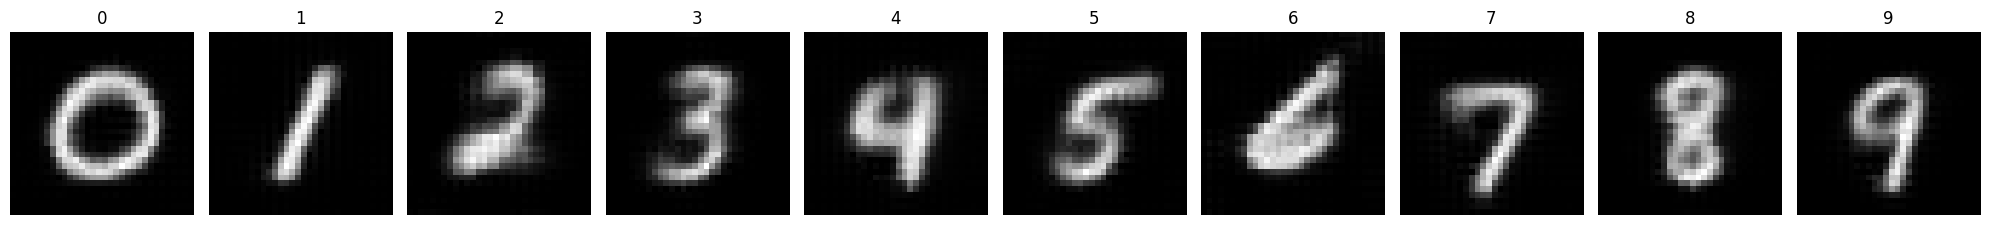

Epoch 18/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1411 - noise_loss: 0.1202 - kl_loss: 2.0902 - val_loss: 0.1400 - val_noise_loss: 0.1200 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.0017 - learning_rate: 7.1289e-04


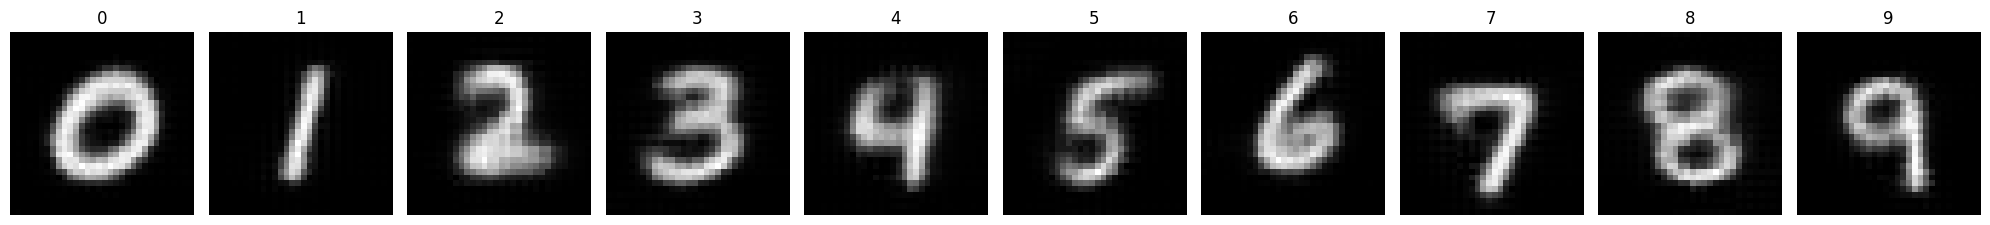

Epoch 19/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1409 - noise_loss: 0.1197 - kl_loss: 2.1185 - val_loss: 0.1394 - val_noise_loss: 0.1191 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.0283 - learning_rate: 6.8406e-04


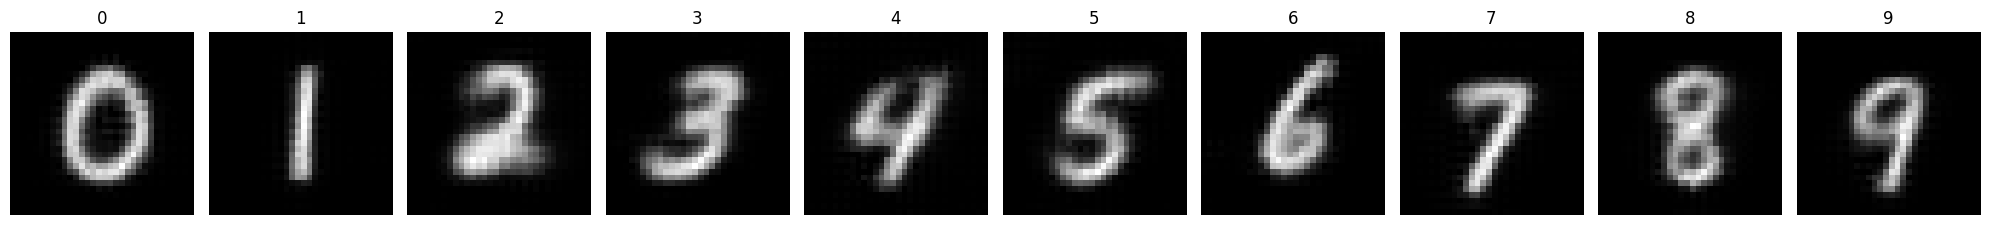

Epoch 20/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1405 - noise_loss: 0.1189 - kl_loss: 2.1590 - val_loss: 0.1391 - val_noise_loss: 0.1185 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.0595 - learning_rate: 6.5451e-04


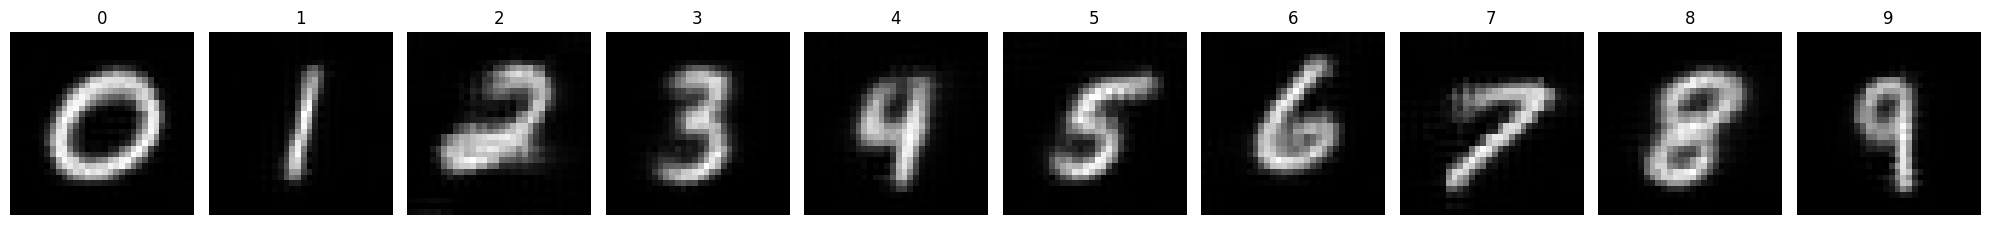

Epoch 21/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1402 - noise_loss: 0.1181 - kl_loss: 2.2077 - val_loss: 0.1391 - val_noise_loss: 0.1182 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.0938 - learning_rate: 6.2435e-04


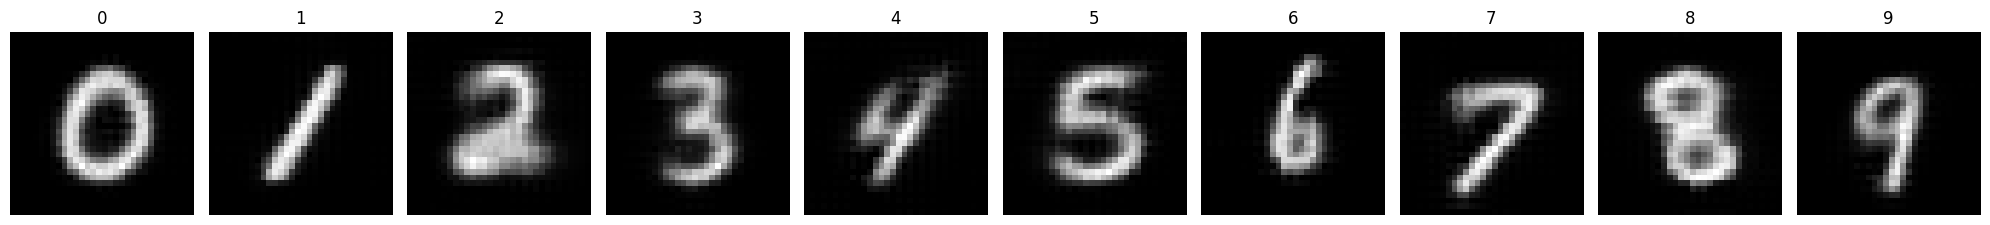

Epoch 22/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1397 - noise_loss: 0.1171 - kl_loss: 2.2582 - val_loss: 0.1384 - val_noise_loss: 0.1171 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.1317 - learning_rate: 5.9369e-04


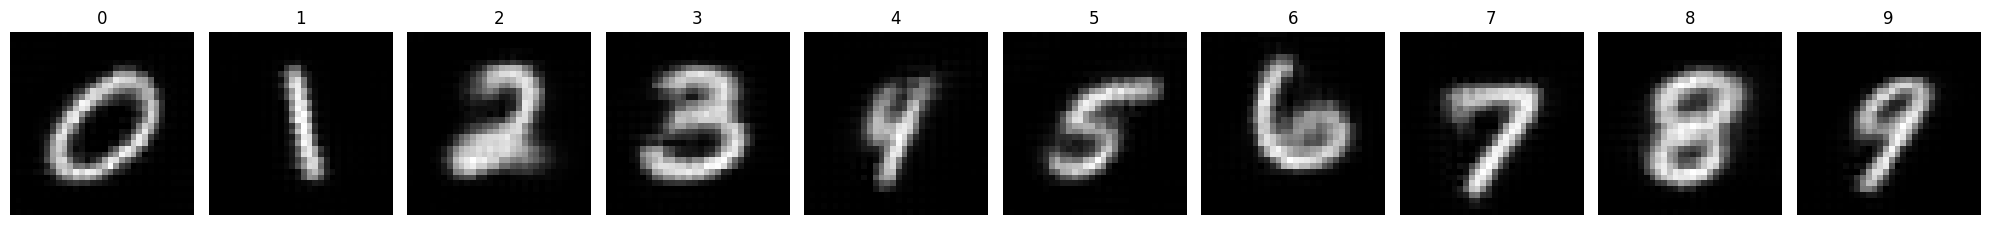

Epoch 23/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1393 - noise_loss: 0.1163 - kl_loss: 2.3001 - val_loss: 0.1379 - val_noise_loss: 0.1162 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.1715 - learning_rate: 5.6267e-04


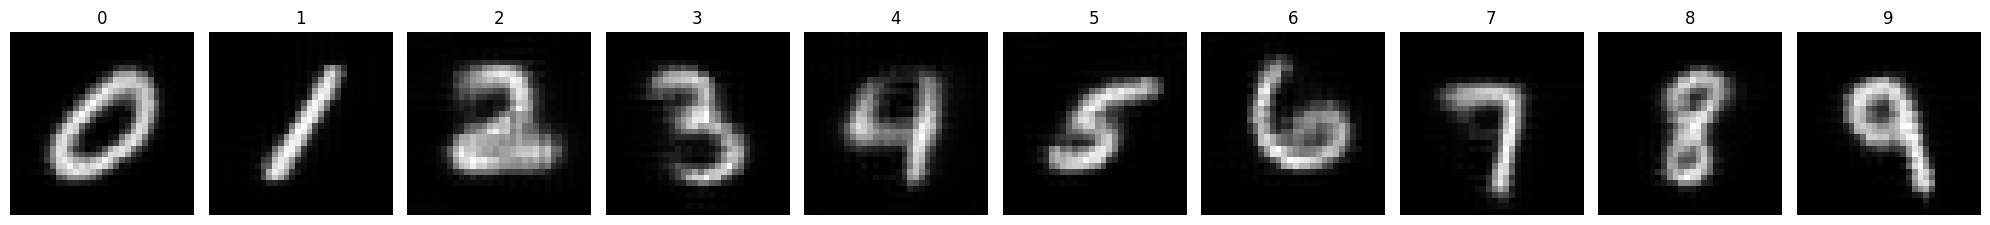

Epoch 24/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1389 - noise_loss: 0.1155 - kl_loss: 2.3400 - val_loss: 0.1378 - val_noise_loss: 0.1157 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.2132 - learning_rate: 5.3140e-04


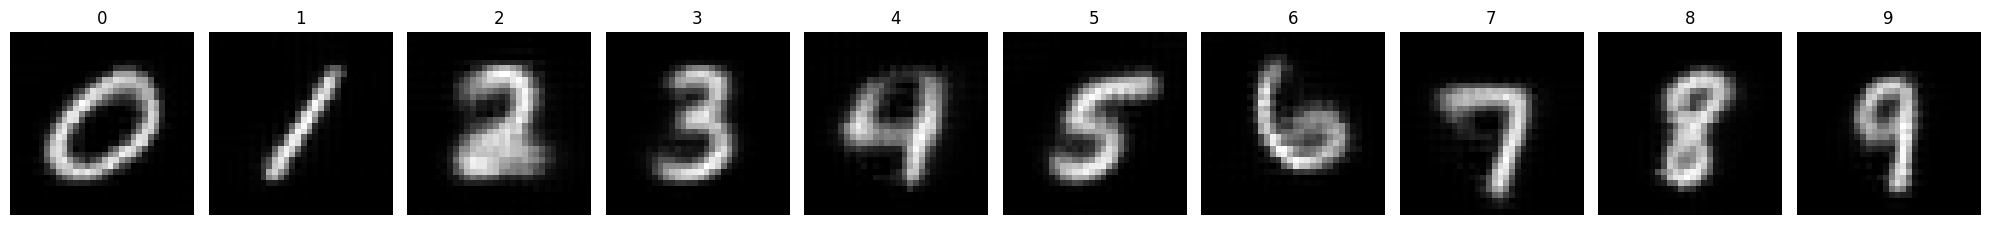

Epoch 25/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1384 - noise_loss: 0.1149 - kl_loss: 2.3511 - val_loss: 0.1373 - val_noise_loss: 0.1148 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.2472 - learning_rate: 5.0000e-04


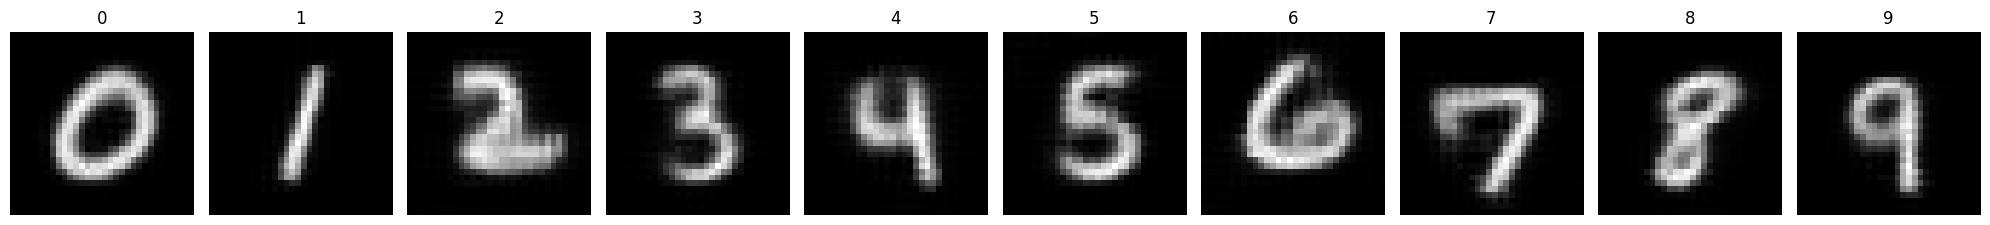

Epoch 26/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1381 - noise_loss: 0.1144 - kl_loss: 2.3737 - val_loss: 0.1368 - val_noise_loss: 0.1140 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.2790 - learning_rate: 4.6860e-04


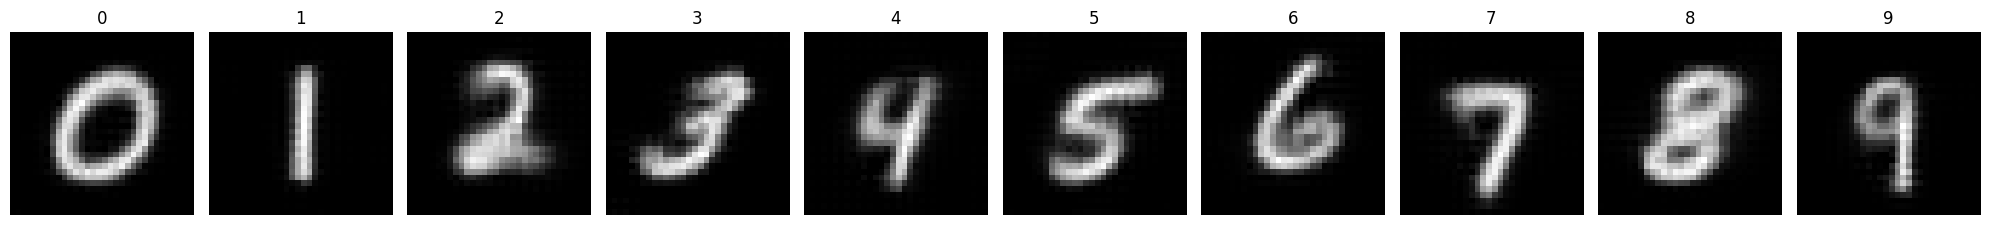

Epoch 27/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1380 - noise_loss: 0.1140 - kl_loss: 2.4017 - val_loss: 0.1370 - val_noise_loss: 0.1139 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.3099 - learning_rate: 4.3733e-04


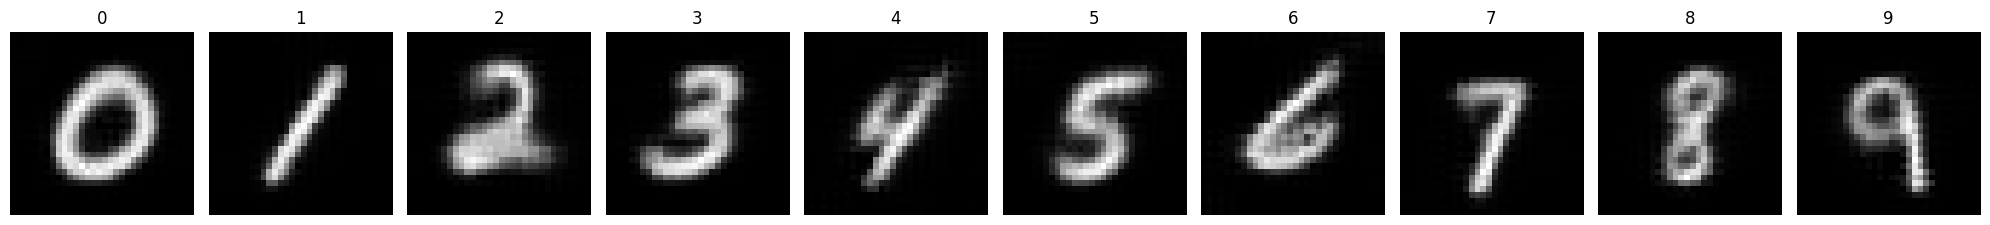

Epoch 28/50
468/468 [==============================] - 49s 106ms/step - loss: 0.1377 - noise_loss: 0.1135 - kl_loss: 2.4175 - val_loss: 0.1364 - val_noise_loss: 0.1130 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.3378 - learning_rate: 4.0631e-04


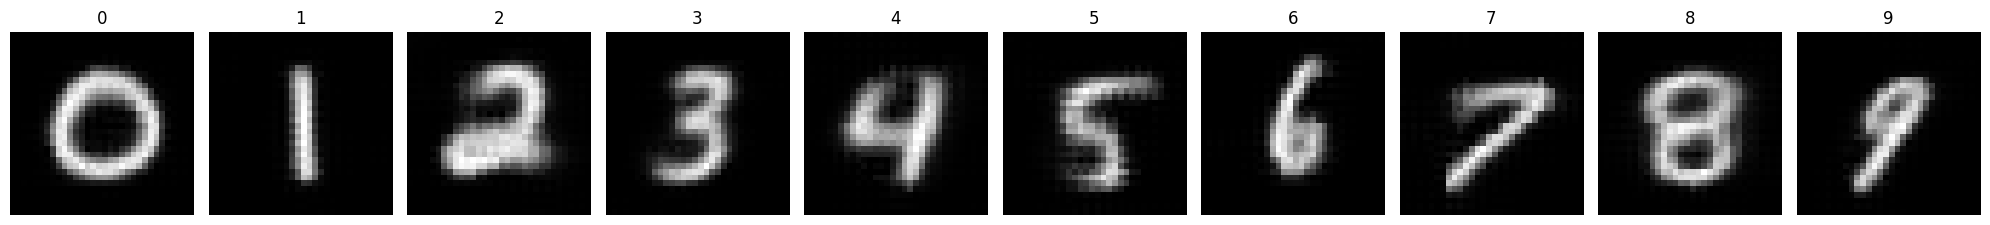

Epoch 29/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1375 - noise_loss: 0.1131 - kl_loss: 2.4373 - val_loss: 0.1366 - val_noise_loss: 0.1129 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.3614 - learning_rate: 3.7566e-04


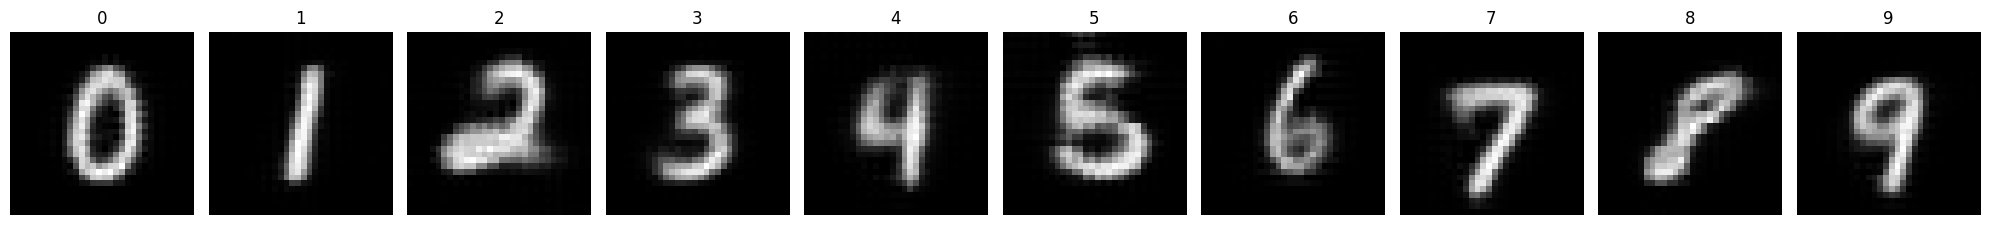

Epoch 30/50
468/468 [==============================] - 51s 108ms/step - loss: 0.1373 - noise_loss: 0.1128 - kl_loss: 2.4535 - val_loss: 0.1361 - val_noise_loss: 0.1123 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.3836 - learning_rate: 3.4549e-04


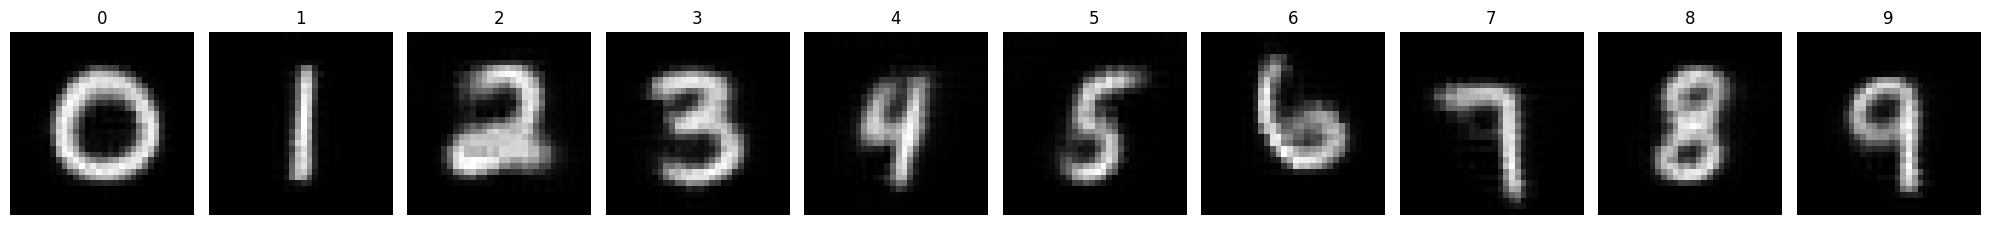

Epoch 31/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1371 - noise_loss: 0.1124 - kl_loss: 2.4654 - val_loss: 0.1363 - val_noise_loss: 0.1123 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4024 - learning_rate: 3.1594e-04


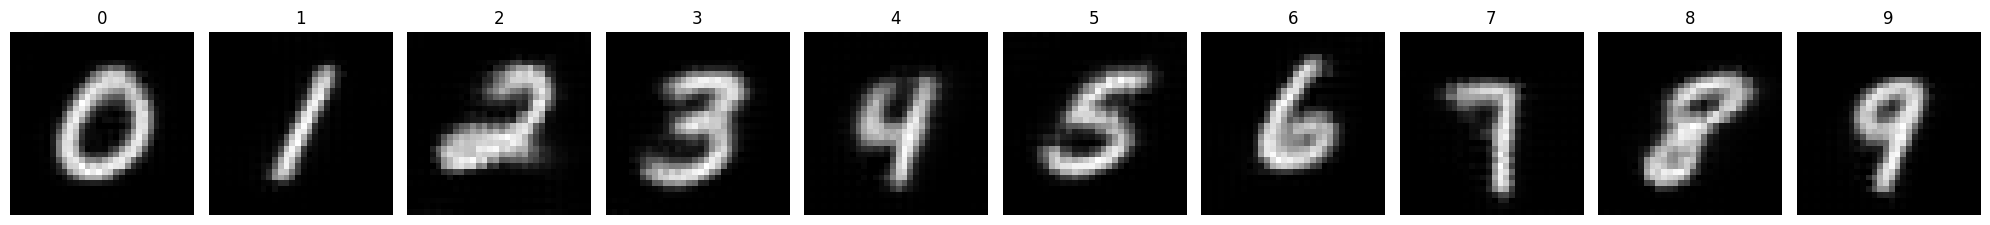

Epoch 32/50
468/468 [==============================] - 50s 108ms/step - loss: 0.1367 - noise_loss: 0.1120 - kl_loss: 2.4684 - val_loss: 0.1359 - val_noise_loss: 0.1118 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4160 - learning_rate: 2.8711e-04


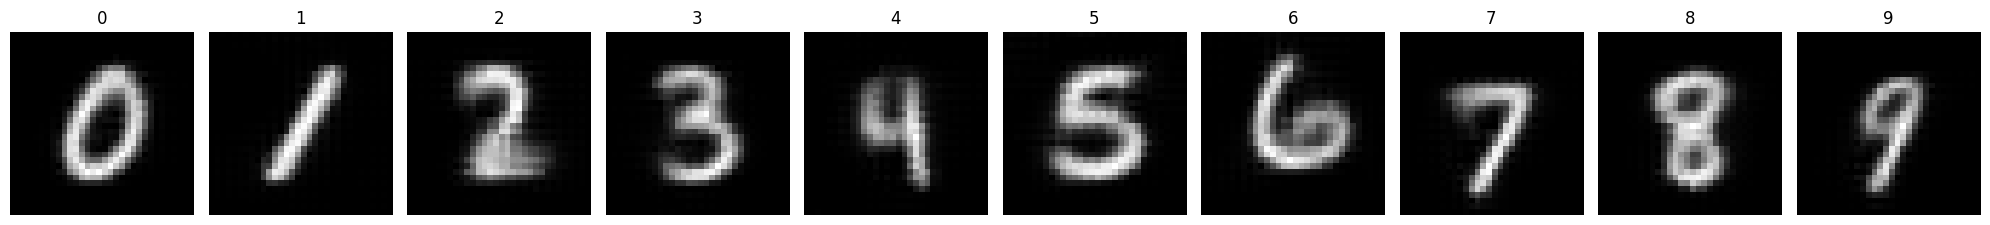

Epoch 33/50
468/468 [==============================] - 51s 108ms/step - loss: 0.1368 - noise_loss: 0.1119 - kl_loss: 2.4873 - val_loss: 0.1361 - val_noise_loss: 0.1118 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4324 - learning_rate: 2.5912e-04


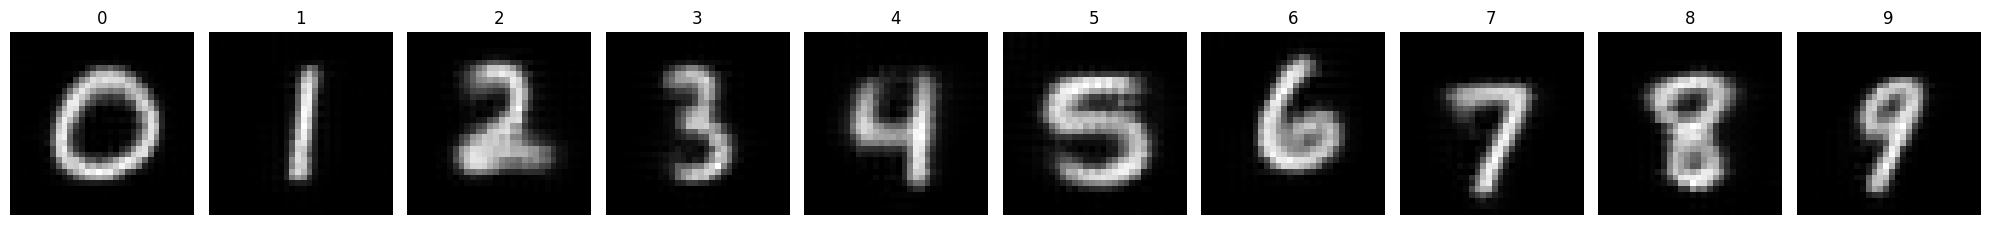

Epoch 34/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1365 - noise_loss: 0.1116 - kl_loss: 2.4869 - val_loss: 0.1356 - val_noise_loss: 0.1111 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4424 - learning_rate: 2.3209e-04


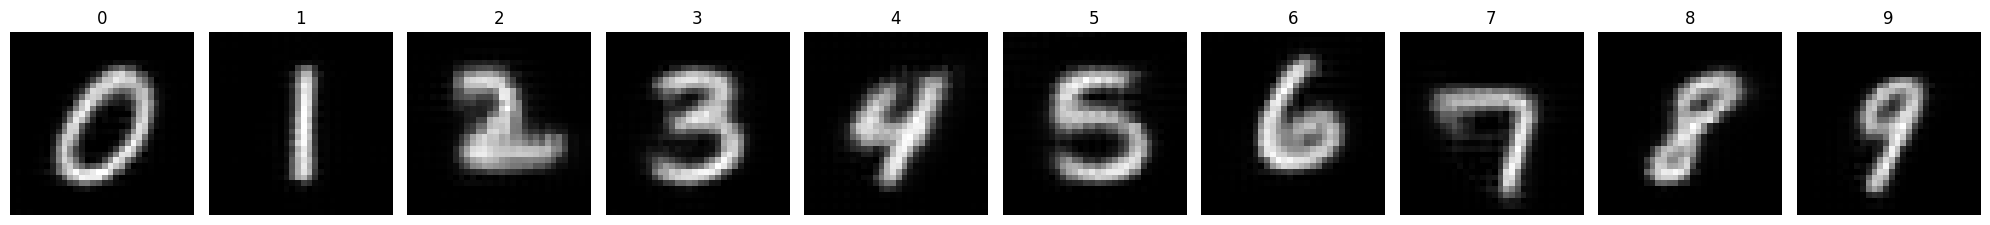

Epoch 35/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1363 - noise_loss: 0.1113 - kl_loss: 2.5020 - val_loss: 0.1357 - val_noise_loss: 0.1111 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4554 - learning_rate: 2.0611e-04


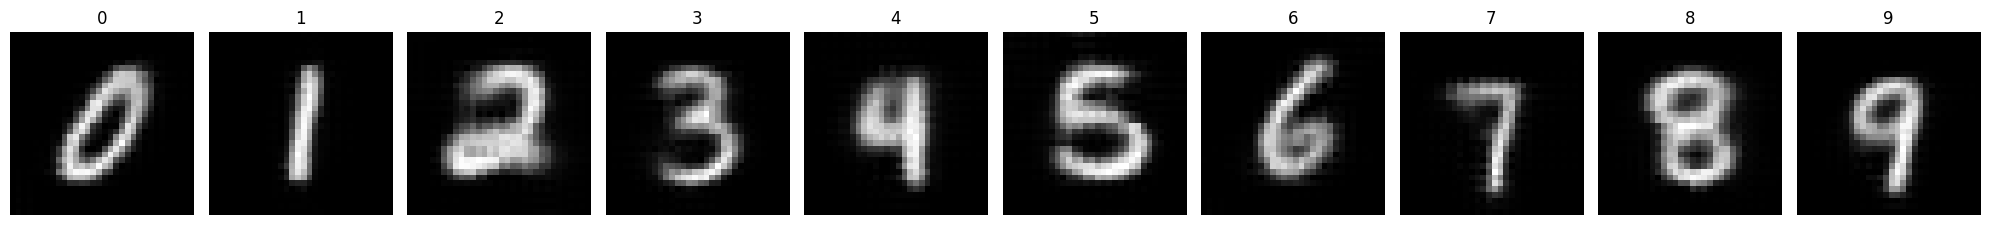

Epoch 36/50
468/468 [==============================] - 51s 108ms/step - loss: 0.1363 - noise_loss: 0.1111 - kl_loss: 2.5202 - val_loss: 0.1357 - val_noise_loss: 0.1110 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4707 - learning_rate: 1.8129e-04


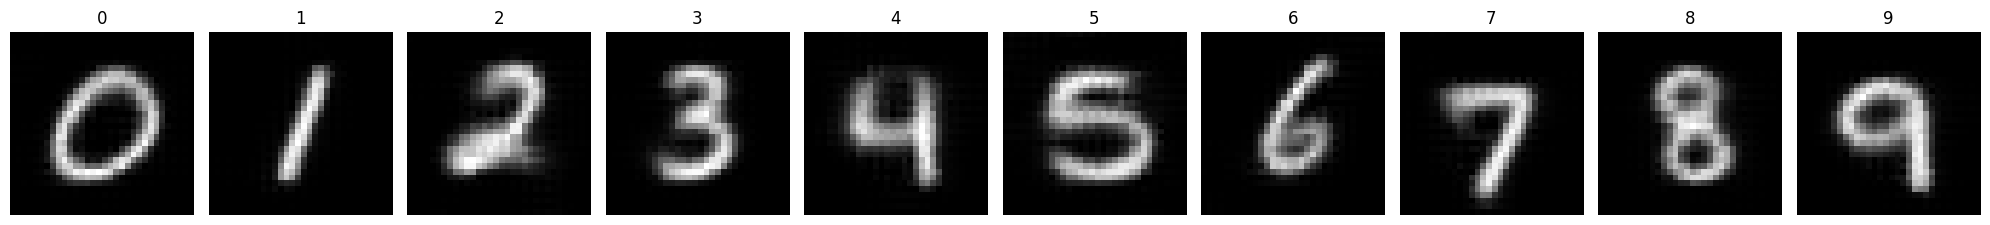

Epoch 37/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1361 - noise_loss: 0.1109 - kl_loss: 2.5185 - val_loss: 0.1353 - val_noise_loss: 0.1105 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4795 - learning_rate: 1.5773e-04


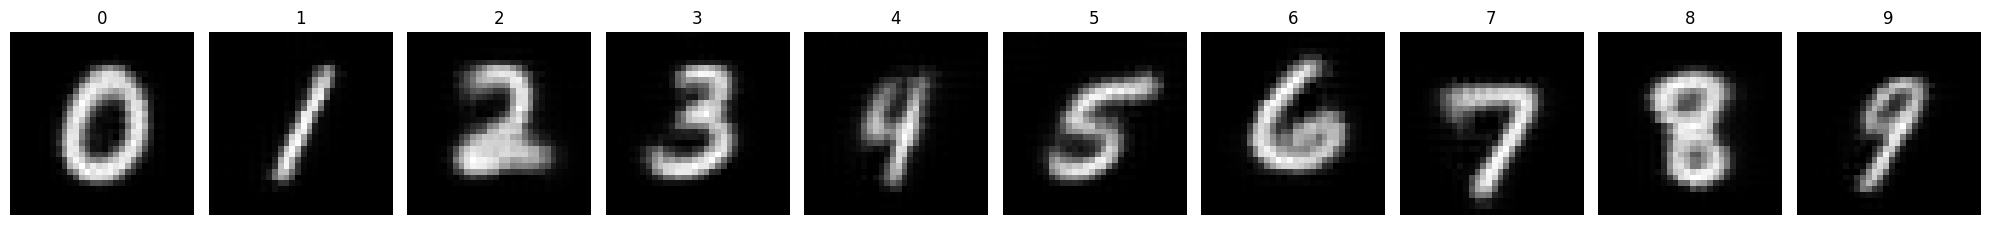

Epoch 38/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1359 - noise_loss: 0.1107 - kl_loss: 2.5206 - val_loss: 0.1356 - val_noise_loss: 0.1108 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4863 - learning_rate: 1.3552e-04


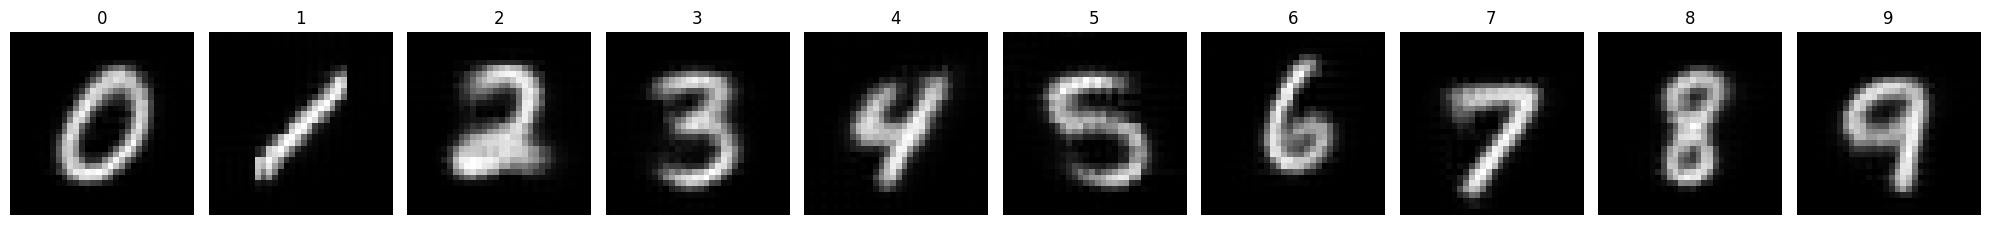

Epoch 39/50
468/468 [==============================] - 49s 104ms/step - loss: 0.1358 - noise_loss: 0.1105 - kl_loss: 2.5283 - val_loss: 0.1352 - val_noise_loss: 0.1103 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.4929 - learning_rate: 1.1474e-04


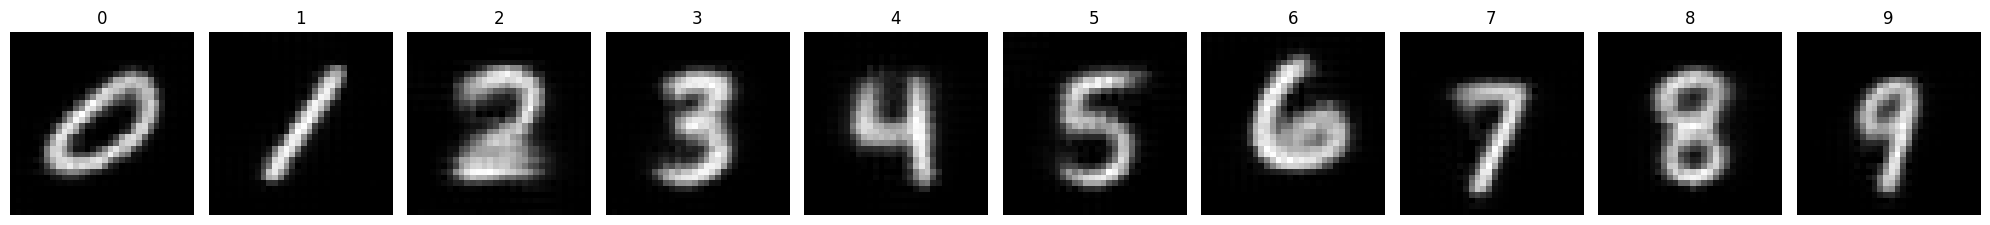

Epoch 40/50
468/468 [==============================] - 50s 106ms/step - loss: 0.1358 - noise_loss: 0.1104 - kl_loss: 2.5393 - val_loss: 0.1351 - val_noise_loss: 0.1101 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5018 - learning_rate: 9.5491e-05


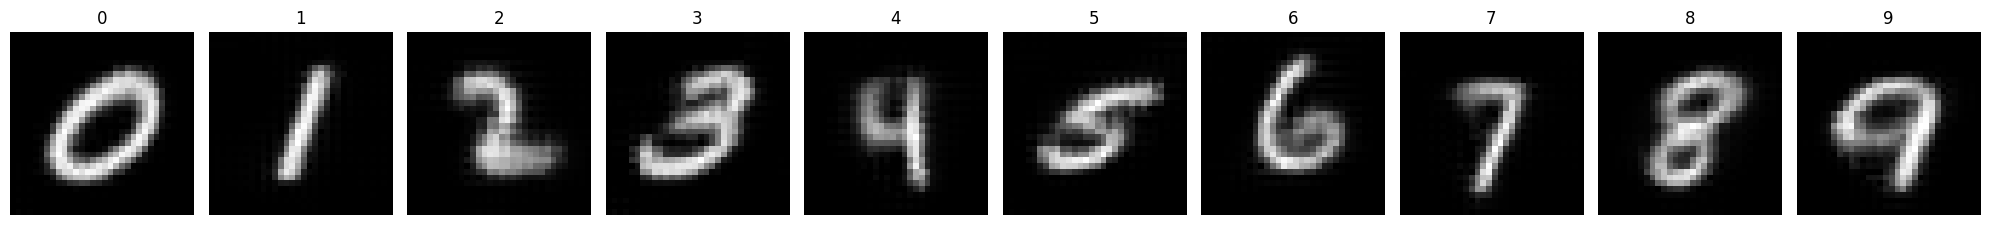

Epoch 41/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1358 - noise_loss: 0.1103 - kl_loss: 2.5502 - val_loss: 0.1352 - val_noise_loss: 0.1101 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5115 - learning_rate: 7.7836e-05


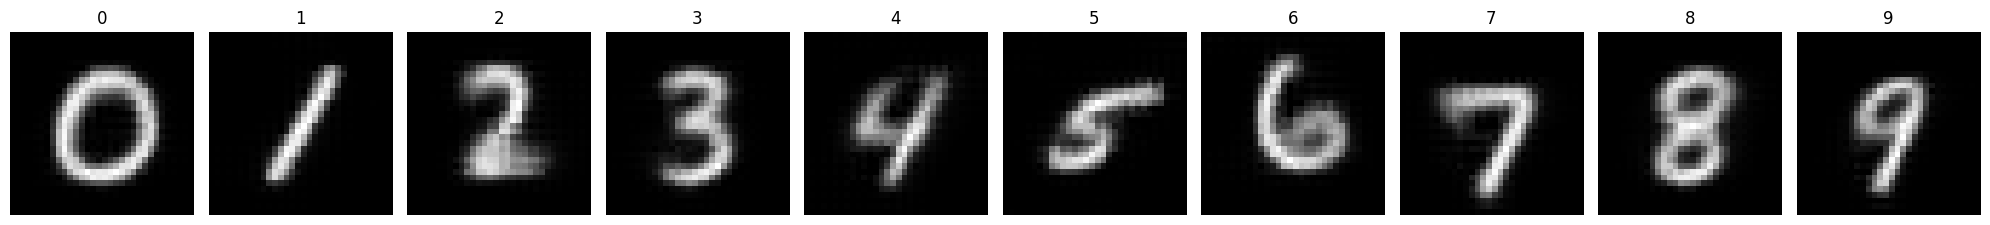

Epoch 42/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1356 - noise_loss: 0.1102 - kl_loss: 2.5384 - val_loss: 0.1350 - val_noise_loss: 0.1099 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5131 - learning_rate: 6.1847e-05


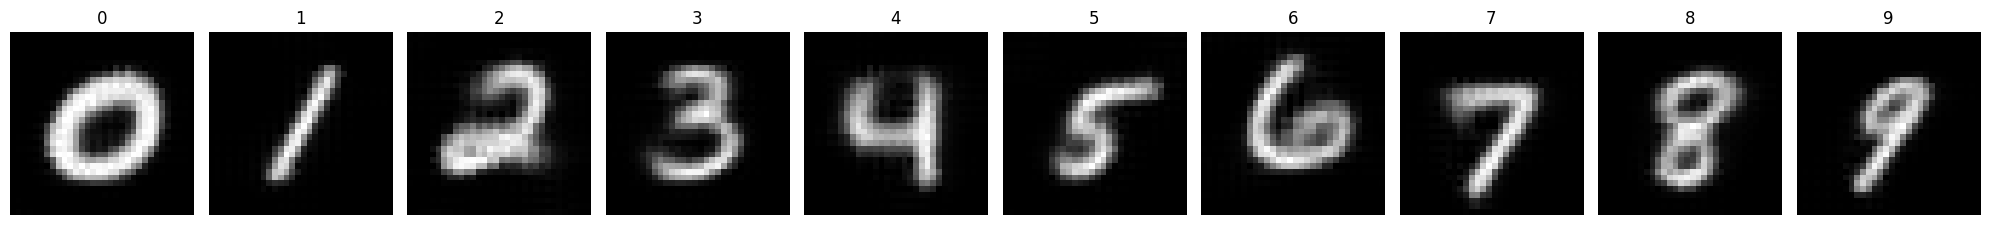

Epoch 43/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1355 - noise_loss: 0.1100 - kl_loss: 2.5530 - val_loss: 0.1353 - val_noise_loss: 0.1101 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5202 - learning_rate: 4.7586e-05


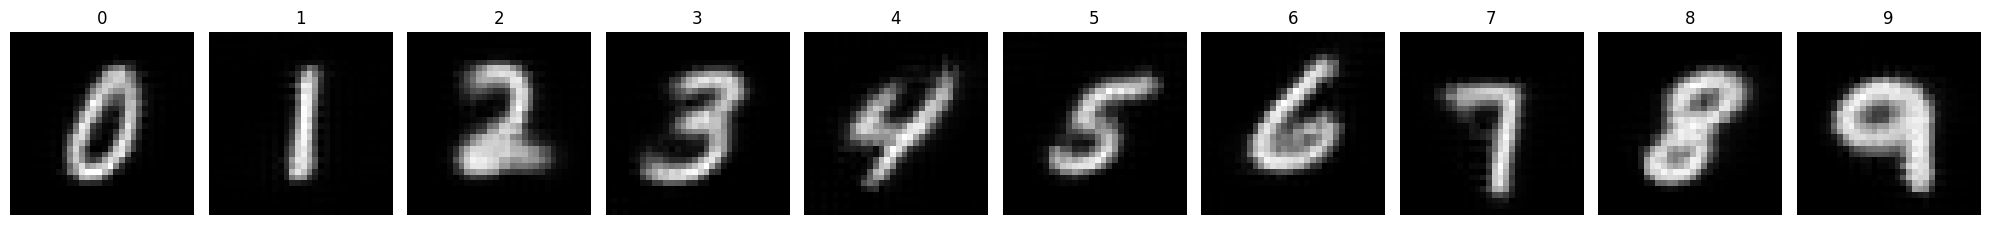

Epoch 44/50
468/468 [==============================] - 51s 110ms/step - loss: 0.1355 - noise_loss: 0.1100 - kl_loss: 2.5514 - val_loss: 0.1351 - val_noise_loss: 0.1098 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5241 - learning_rate: 3.5112e-05


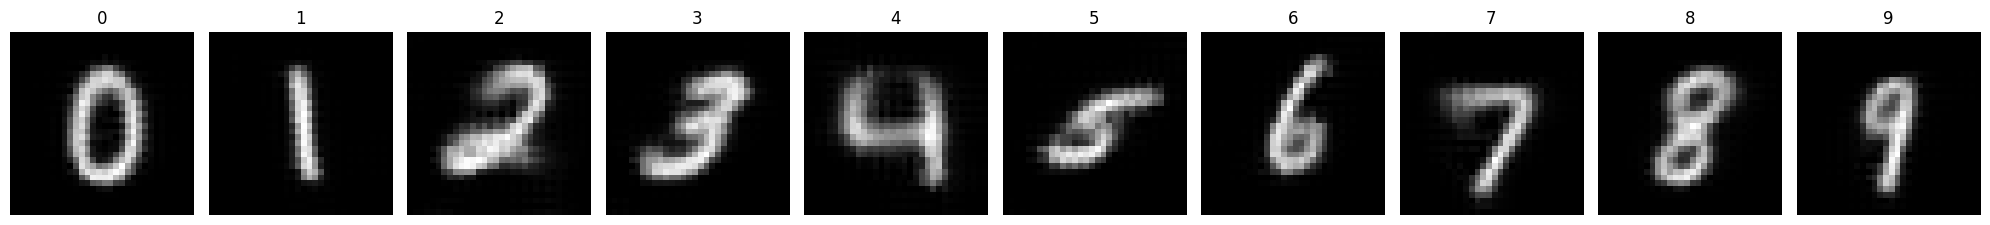

Epoch 45/50
468/468 [==============================] - 50s 108ms/step - loss: 0.1353 - noise_loss: 0.1099 - kl_loss: 2.5459 - val_loss: 0.1352 - val_noise_loss: 0.1099 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5249 - learning_rate: 2.4472e-05


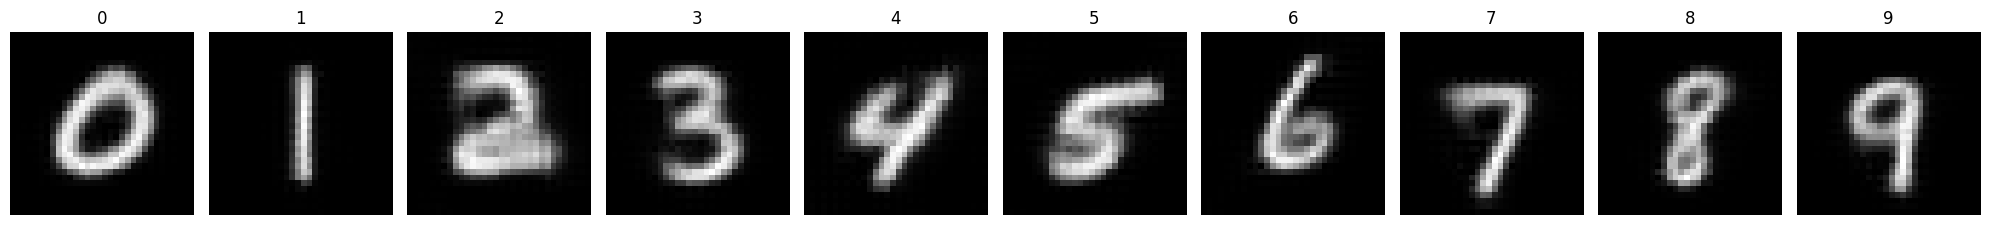

Epoch 46/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1353 - noise_loss: 0.1098 - kl_loss: 2.5472 - val_loss: 0.1348 - val_noise_loss: 0.1096 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5259 - learning_rate: 1.5708e-05


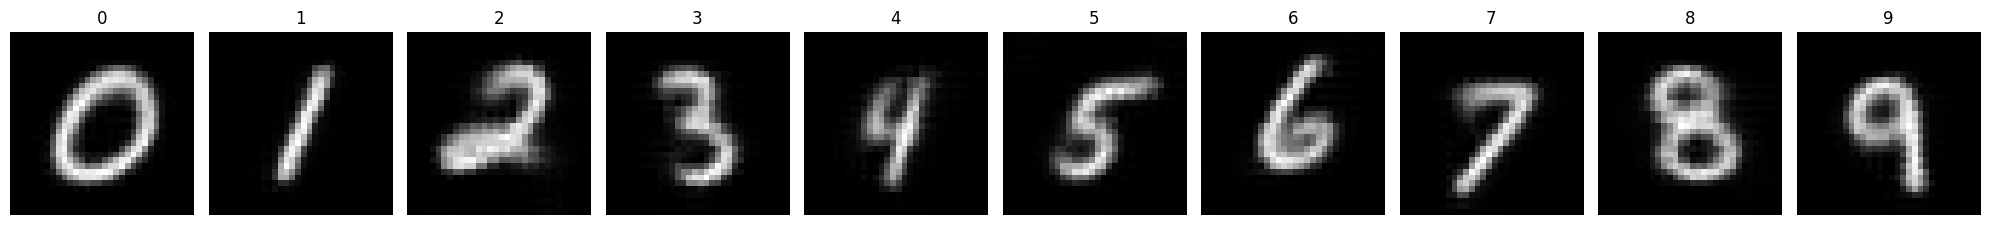

Epoch 47/50
468/468 [==============================] - 50s 108ms/step - loss: 0.1353 - noise_loss: 0.1098 - kl_loss: 2.5536 - val_loss: 0.1351 - val_noise_loss: 0.1098 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5289 - learning_rate: 8.8564e-06


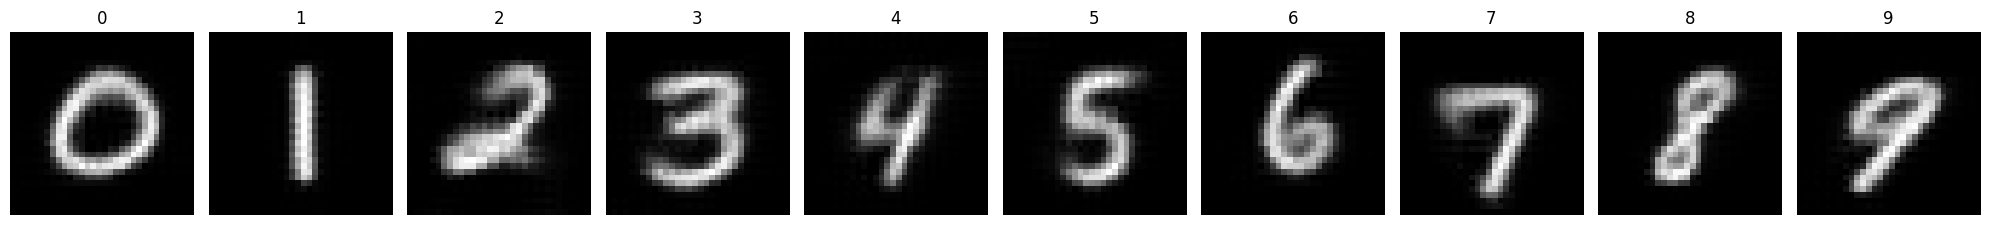

Epoch 48/50
468/468 [==============================] - 51s 110ms/step - loss: 0.1353 - noise_loss: 0.1098 - kl_loss: 2.5567 - val_loss: 0.1350 - val_noise_loss: 0.1097 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5320 - learning_rate: 3.9426e-06


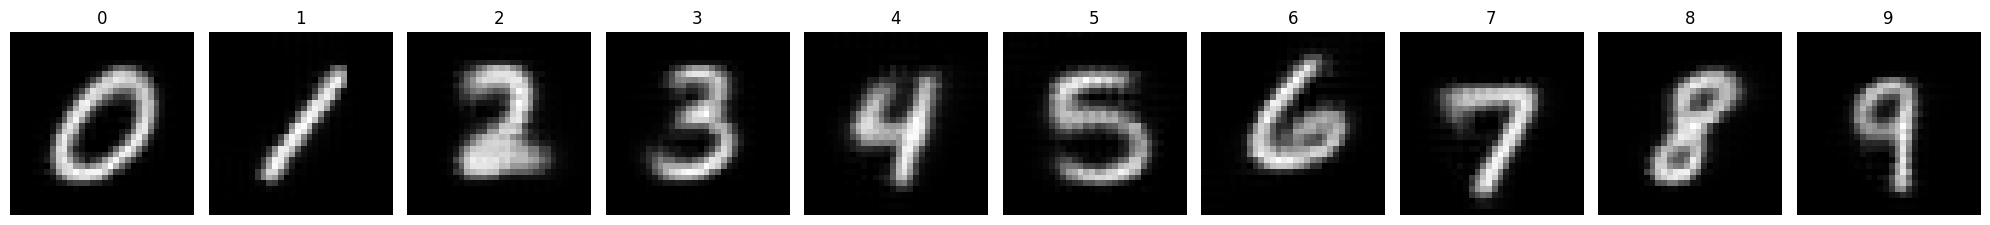

Epoch 49/50
468/468 [==============================] - 51s 109ms/step - loss: 0.1354 - noise_loss: 0.1097 - kl_loss: 2.5651 - val_loss: 0.1348 - val_noise_loss: 0.1094 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5369 - learning_rate: 9.8664e-07


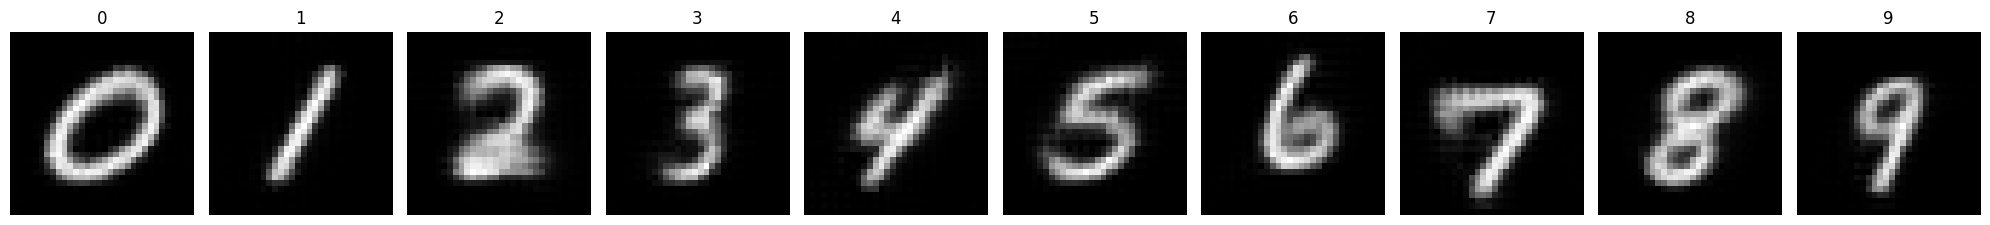

Epoch 50/50
468/468 [==============================] - 50s 107ms/step - loss: 0.1353 - noise_loss: 0.1097 - kl_loss: 2.5622 - val_loss: 0.1349 - val_noise_loss: 0.1095 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5390 - learning_rate: 0.0000e+00


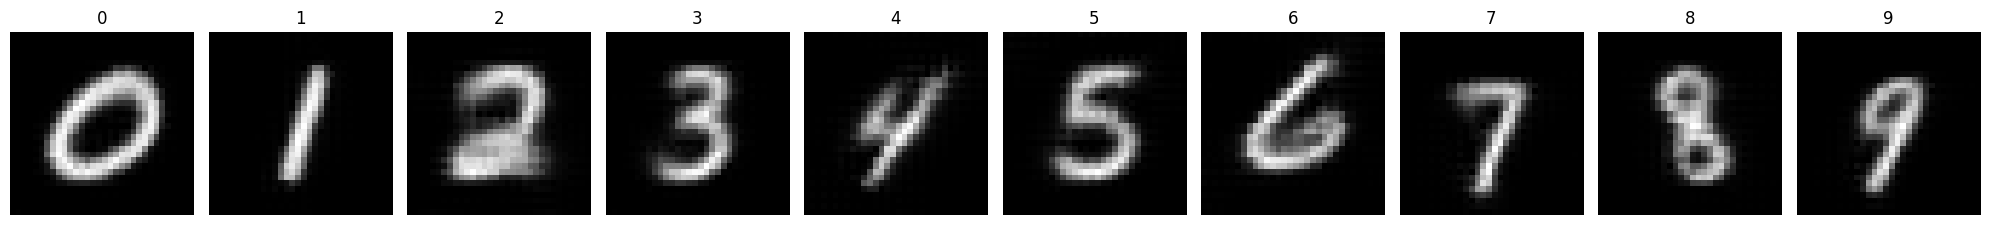

In [12]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
).history

In [13]:
# history = model.fit_progressively(
#     x=trainset.take(1), 
#     num_stages=10, 
#     stage_epochs=epochs, 
#     pacing_type="plateau", 
#     monitor="val_noise_loss", 
#     min_delta=1e-3, 
#     patience=1, 
#     validation_data=valset, 
#     callbacks=callbacks_list, 
# ).history

In [14]:
model.evaluate(valset)

79/79 [==============================] - 7s 55ms/step - loss: 0.1350 - noise_loss: 0.1096 - image_loss: 0.0000e+00 - kl_loss: 2.5390


[0.13500338792800903, 0.10961384326219559, 0.0, 2.538954973220825]

In [15]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 6s 57ms/step - loss: 0.1351 - noise_loss: 0.1097 - image_loss: 0.0000e+00 - kl_loss: 2.5421


[0.13508635759353638, 0.10966523736715317, 0.0, 2.5421111583709717]

In [16]:
from common.utils import plot_images


# imgs = model.sample(labels=list(range(11)), scale=3., steps=1_000, eta=1., verbose=True)
# plot_images(imgs)

In [17]:
# model.set_current_resolution(32)

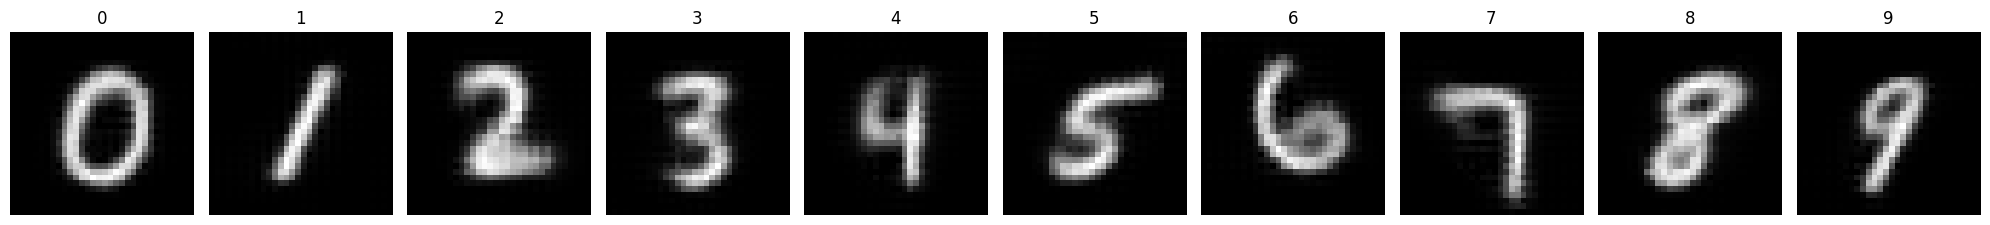

In [18]:
imgs = model.sample(labels=list(range(10)), verbose=True)
plot_images(imgs)

In [19]:
# imgs = model.sample(labels=list(range(11)), verbose=True)
# plot_images(imgs)

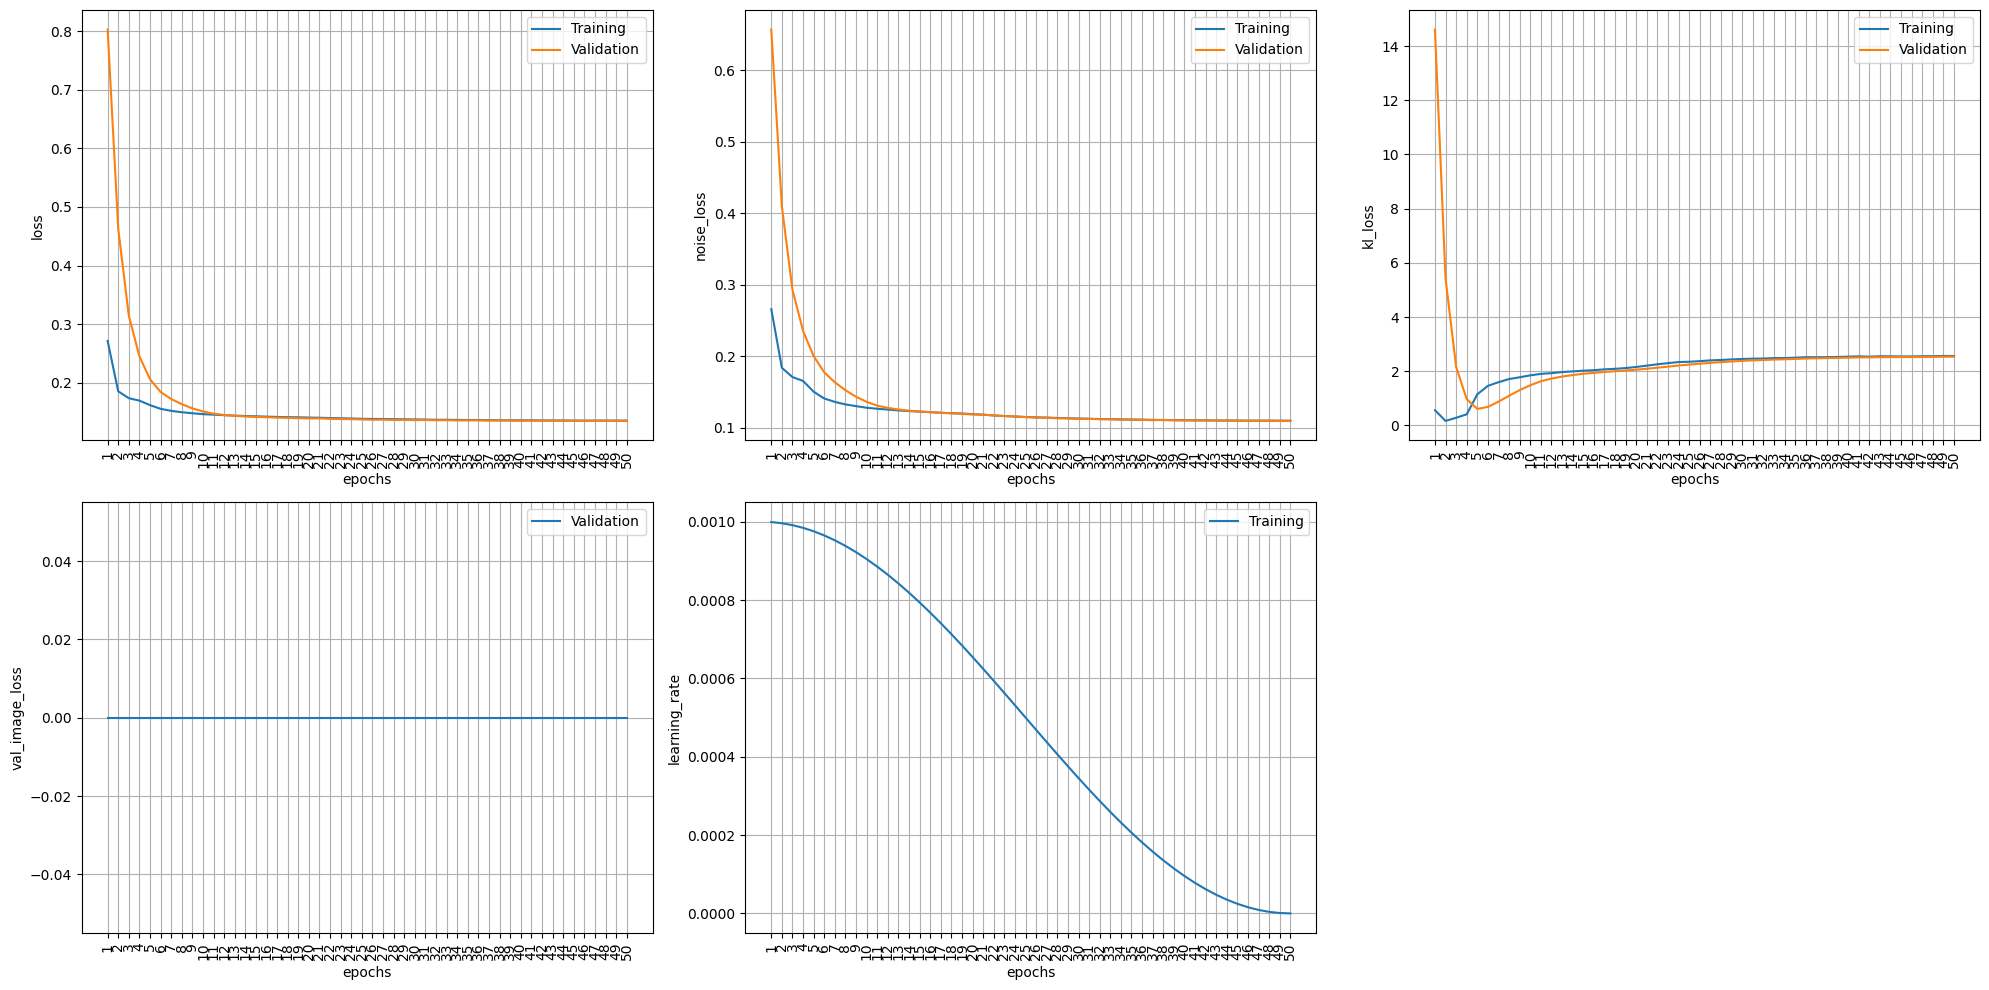

In [20]:
from common.utils import plot_history


plot_history(history)

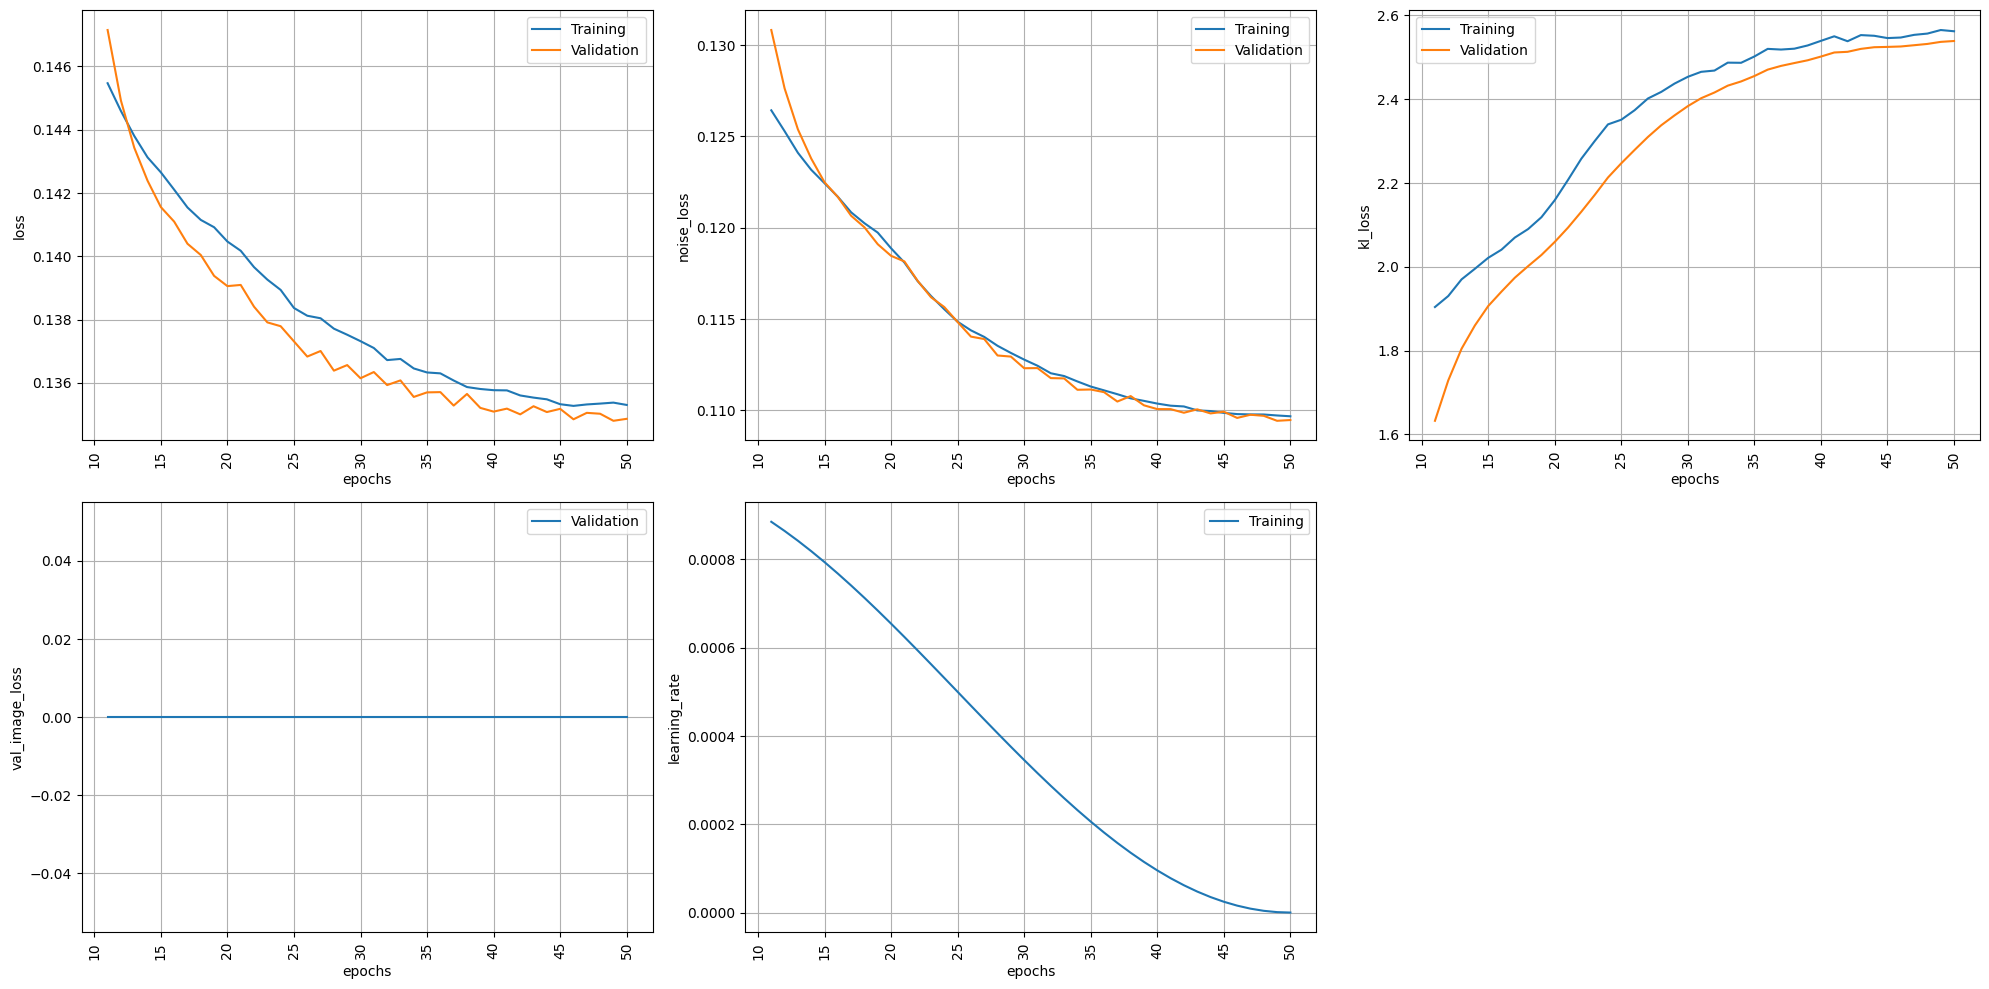

In [21]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))